In [1]:
# TensorFlow and tf.keras 
import tensorflow as tf 
# Helper libraries 
import numpy as np 
import matplotlib.pyplot as plt 
print(tf.__version__)

C:\Users\Anshu1106\anaconda\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"



2.15.0


In [3]:
fashion_mnist = tf.keras.datasets.fashion_mnist 
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

4422102/4422102 [==============================] - 1s 0us/step


In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [5]:
train_images.shape

(60000, 28, 28)

In [6]:
len(train_labels)

60000

In [7]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [8]:
test_images.shape

(10000, 28, 28)

In [9]:
len(test_labels)

10000

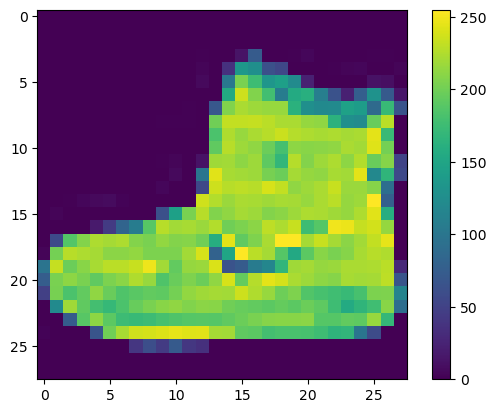

In [10]:
plt.figure() 
plt.imshow(train_images[0])
plt.colorbar() 
plt.grid(False) 
plt.show()

In [11]:
train_images = train_images / 255.0 
test_images = test_images / 255.0

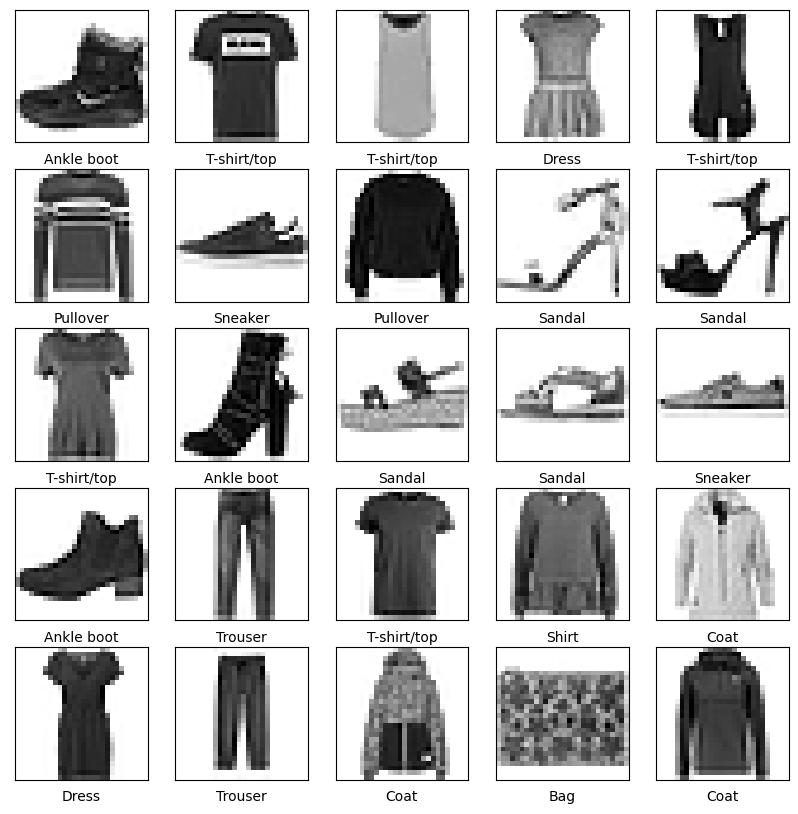

In [12]:
plt.figure(figsize=(10,10)) 
for i in range(25): 
    plt.subplot(5,5,i+1) 
    plt.xticks([]) 
    plt.yticks([]) 
    plt.grid(False) 
    plt.imshow(train_images[i], cmap=plt.cm.binary) 
    plt.xlabel(class_names[train_labels[i]]) 
plt.show()

In [13]:
model = tf.keras.Sequential([ tf.keras.layers.Flatten(input_shape=(28, 28)), 
tf.keras.layers.Dense(128, activation='relu'), tf.keras.layers.Dense(10) ])

In [14]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [15]:
history = model.fit( train_images, train_labels, epochs=10, batch_size=32, validation_split=0.2 )

Epoch 1/10


1500/1500 [==============================] - 7s 4ms/step - loss: 0.5147 - accuracy: 0.8197 - val_loss: 0.4272 - val_accuracy: 0.8496
Epoch 2/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3856 - accuracy: 0.8621 - val_loss: 0.3906 - val_accuracy: 0.8569
Epoch 3/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3493 - accuracy: 0.8733 - val_loss: 0.3726 - val_accuracy: 0.8636
Epoch 4/10
1500/1500 [==============================] - 7s 5ms/step - loss: 0.3200 - accuracy: 0.8843 - val_loss: 0.3527 - val_accuracy: 0.8731
Epoch 5/10
1500/1500 [==============================] - 5s 4ms/step - loss: 0.3014 - accuracy: 0.8888 - val_loss: 0.3385 - val_accuracy: 0.8784
Epoch 6/10
1500/1500 [==============================] - 5s 4ms/step - loss: 0.2852 - accuracy: 0.8950 - val_loss: 0.3384 - val_accuracy: 0.8782
Epoch 7/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2723 - accuracy: 0.8987 - val_loss: 0.3300 - val_accurac

In [17]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2) 
print('\nTest accuracy:', test_acc)

313/313 - 0s - loss: 0.3599 - accuracy: 0.8752 - 414ms/epoch - 1ms/step

Test accuracy: 0.8751999735832214


In [18]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(test_images)

313/313 [==============================] - 0s 1ms/step


In [19]:
predictions[0]

array([5.9944045e-06, 1.1721424e-08, 4.4564352e-08, 9.0881915e-09,
       7.9083826e-08, 4.5478035e-04, 3.7298827e-07, 1.9668287e-03,
       1.2735794e-08, 9.9757189e-01], dtype=float32)

In [20]:
np.argmax(predictions[0])

9

In [21]:
test_labels[0]

9

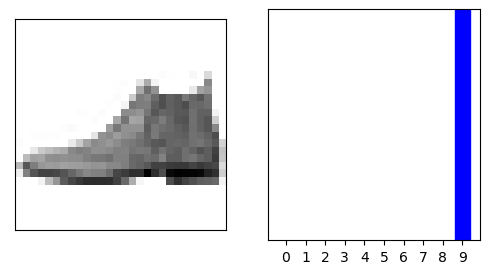

In [23]:
def plot_image(i, predictions_array, true_label, img): 
    true_label, img = true_label[i], img[i] 
    plt.grid(False) 
    plt.xticks([]) 
    plt.yticks([]) 
    plt.imshow(img, cmap=plt.cm.binary) 
    predicted_label = np.argmax(predictions_array) 
    if predicted_label == true_label: 
        color = 'blue' 
    else: 
        color = 'red' 
        plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label], 100*np.max(predictions_array), 
        class_names[true_label]), color=color) 
        
def plot_value_array(i, predictions_array, true_label): 
    true_label = true_label[i] 
    plt.grid(False) 
    plt.xticks(range(10)) 
    plt.yticks([]) 
    thisplot = plt.bar(range(10), predictions_array, color="#777777") 
    plt.ylim([0, 1]) 
    predicted_label = np.argmax(predictions_array) 
    thisplot[predicted_label].set_color('red') 
    thisplot[true_label].set_color('blue')
    
i = 0 
plt.figure(figsize=(6,3)) 
plt.subplot(1,2,1) 
plot_image(i, predictions[i], test_labels, test_images) 
plt.subplot(1,2,2) 
plot_value_array(i, predictions[i], test_labels) 
plt.show()

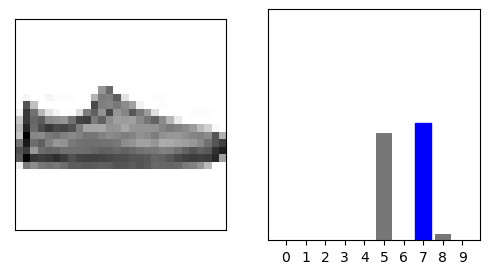

In [24]:
i = 12 
plt.figure(figsize=(6,3)) 
plt.subplot(1,2,1) 
plot_image(i, predictions[i], test_labels, test_images) 
plt.subplot(1,2,2) 
plot_value_array(i, predictions[i], test_labels) 
plt.show()

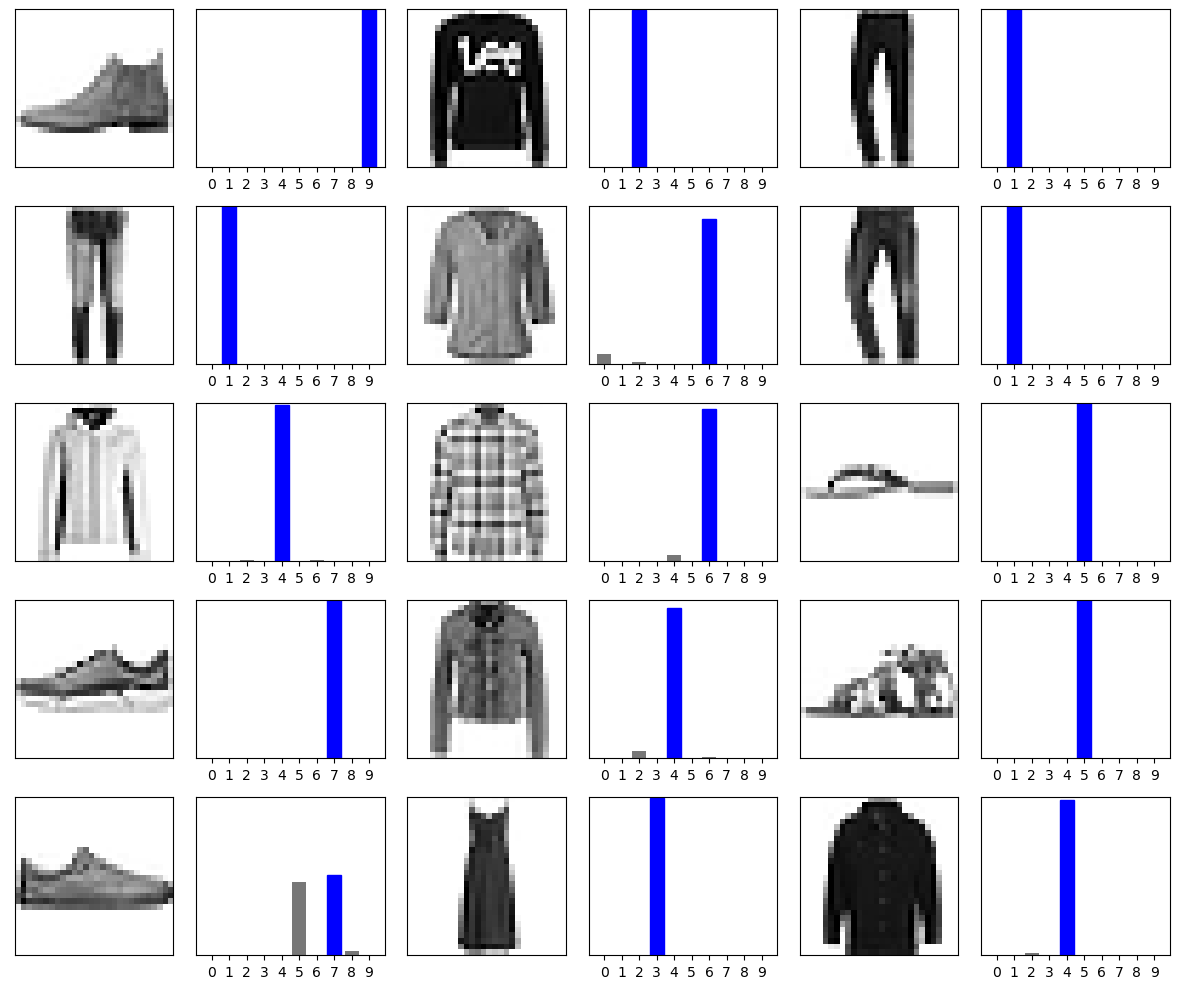

In [25]:
# Plot the first X test images, their predicted labels, and the true labels. 
# Color correct predictions in blue and incorrect predictions in red. 
num_rows = 5 
num_cols = 3 
num_images = num_rows*num_cols 
plt.figure(figsize=(2*2*num_cols, 2*num_rows)) 
for i in range(num_images): 
    plt.subplot(num_rows, 2*num_cols, 2*i+1) 
    plot_image(i, predictions[i], test_labels, test_images) 
    plt.subplot(num_rows, 2*num_cols, 2*i+2) 
    plot_value_array(i, predictions[i], test_labels) 
    plt.tight_layout() 
plt.show()

In [26]:
# Grab an image from the test dataset. 
img = test_images[1] 
print(img.shape)

(28, 28)


In [27]:
# Add the image to a batch where it's the only member. 
img = (np.expand_dims(img,0)) 
print(img.shape)

(1, 28, 28)


In [29]:
predictions_single = probability_model.predict(img) 
print(predictions_single)

1/1 [==============================] - 0s 19ms/step
[[3.2287146e-06 1.2970550e-11 9.9571252e-01 2.5959255e-09 3.7716867e-03
  7.0675349e-15 5.1249826e-04 2.2445485e-12 2.3266840e-09 5.9599777e-12]]


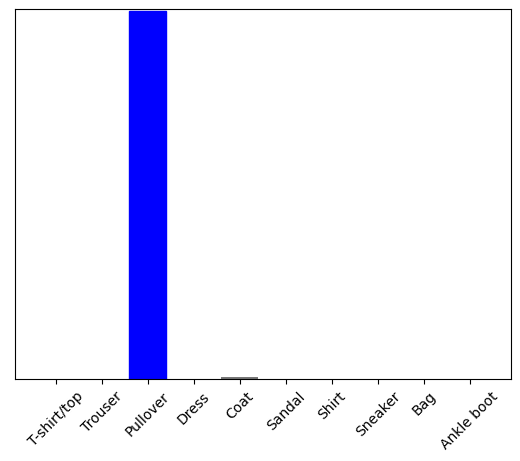

In [32]:
plot_value_array(1, predictions_single[0], test_labels) 
_ = plt.xticks(range(10), class_names, rotation=45) 
plt.show()

In [33]:
np.argmax(predictions_single[0])

2